# 02 Data Transformation
This notebook covers the data augmentation and normalization transformations used for training and testing the pneumonia classifier.

In [1]:
import os
import torch
from torchvision import transforms, datasets
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

# Define paths
data_dir = r'j:\Users\ayush\Desktop\code\pneumonia_classifier\artifacts\02_12_2025_08_52_04\data_ingestion\data\data'
train_dir = os.path.join(data_dir, 'train')

# Define constants (matching production pipeline)
RESIZE = 224
CENTERCROP = 224
RANDOMROTATION = 10
NORMALIZE_MEAN = [0.485, 0.456, 0.406]
NORMALIZE_STD = [0.229, 0.224, 0.225]

## Training Transformations
We use several augmentations to increase model robustness.

In [2]:
train_transform = transforms.Compose([
    transforms.Resize(RESIZE),
    transforms.CenterCrop(CENTERCROP),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.1),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(RANDOMROTATION),
    transforms.ToTensor(),
    transforms.Normalize(mean=NORMALIZE_MEAN, std=NORMALIZE_STD)
])

print("Training transformations defined.")

Training transformations defined.


## Visualization of Transformed Images

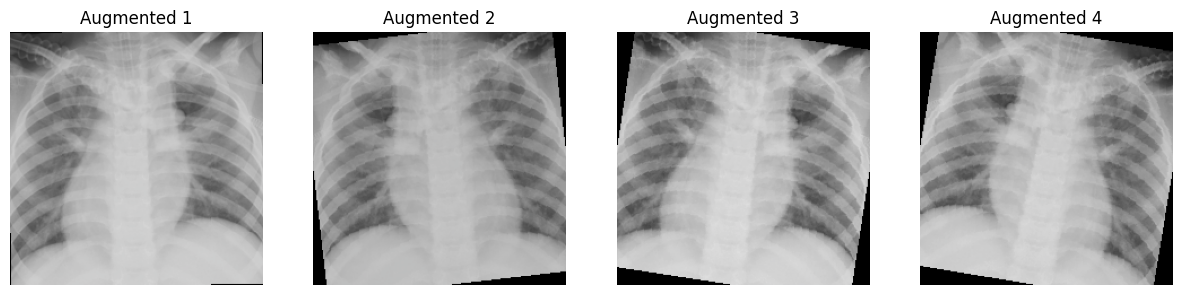

In [3]:
def imshow(img, title=None):
    img = img.numpy().transpose((1, 2, 0))
    mean = np.array(NORMALIZE_MEAN)
    std = np.array(NORMALIZE_STD)
    img = std * img + mean
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    if title is not None:
        plt.title(title)
    plt.axis('off')

# Load a single image and apply transform multiple times to see augmentation effects
cls = 'PNEUMONIA'
img_path = os.path.join(train_dir, cls, os.listdir(os.path.join(train_dir, cls))[0])
img = Image.open(img_path).convert('RGB')

plt.figure(figsize=(15, 5))
for i in range(4):
    transformed_img = train_transform(img)
    plt.subplot(1, 4, i+1)
    imshow(transformed_img, f"Augmented {i+1}")
plt.show()